# **Keşifçi Veri Analizi (Exploratory Data Analysis - EDA)**

###  Kütüphanelerin Yüklenmesi

In [33]:
# temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

#istatistik kütüphaneleri
from scipy import stats
import warnings

# ayarlar
warnings.filterwarnings('ignore') # uyarı mesajlarını kapatır
pd.set_option('display.max_columns', 50)# büyük veri de gelecek columm sayısını sınırlar
pd.set_option('display.max_rows', None)# satırı sınırlar
pd.set_option('display.float_format', lambda x: '%.2f' % x)#ekranda virgülden sonra kaç basamak

#Grafik stili ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize']= (12,8)
plt.rcParams['font.size']= 12

print('Tüm kütüphaneler başarıyla yüklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

print(f'Seaborn version: {sns.__version__}')

Tüm kütüphaneler başarıyla yüklendi
Pandas version: 2.2.2
Numpy version: 2.0.2
Seaborn version: 0.13.2


## Veri yükleme

In [34]:
df = pd.read_csv('Cuisine_rating.csv')

In [41]:
# İlk 5 satırı göster
df.head()

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
0,1,153,"Upper East Side,NY",Female,2006,Single,Professional,3,Japanese,Never,Never,5,4,4.50,No
1,2,123,"St. George,NY",Female,1991,Married,Student,3,Indian,Never,Socially,1,1,1.00,No
2,3,122,"Upper West Side,NY",Male,1977,Single,Student,5,Seafood,Often,Often,5,5,5.00,Yes
3,4,153,"Upper East Side,NY",Female,1956,Married,Professional,5,Japanese,Never,Socially,3,1,2.00,No
4,5,129,"Central Park,NY",Male,1997,Single,Student,4,Filipino,Socially,Never,2,4,3.00,No


In [42]:
df.head(3)

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
0,1,153,"Upper East Side,NY",Female,2006,Single,Professional,3,Japanese,Never,Never,5,4,4.50,No
1,2,123,"St. George,NY",Female,1991,Married,Student,3,Indian,Never,Socially,1,1,1.00,No
2,3,122,"Upper West Side,NY",Male,1977,Single,Student,5,Seafood,Often,Often,5,5,5.00,Yes


In [43]:
df.tail()

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
195,196,175,"St. George,NY",Female,1982,Single,Professional,4,French,Never,Socially,1,2,1.50,No
196,197,170,"Upper West Side,NY",Female,2000,Married,Student,4,Chinese,Never,Often,1,2,1.50,No
197,198,160,"St. George,NY",Female,2006,Single,Professional,5,Japanese,Never,Often,5,2,3.50,No
198,199,130,"St. George,NY",Male,2002,Married,Student,3,Filipino,Never,Socially,3,2,2.50,No
199,200,140,"Upper East Side,NY",Male,2005,Married,Student,4,French,Never,Never,3,2,2.50,No


In [44]:
df.tail(2)

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
198,199,130,"St. George,NY",Male,2002,Married,Student,3,Filipino,Never,Socially,3,2,2.50,No
199,200,140,"Upper East Side,NY",Male,2005,Married,Student,4,French,Never,Never,3,2,2.50,No


In [45]:
#rastgele beş satır
df.sample(5)

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
56,57,123,"St. George,NY",Female,1981,Divorced,Student,2,Italian,Socially,Often,5,5,5.00,No
144,145,199,"St. George,NY",Female,1969,Married,Professional,3,Italian,Often,Never,4,1,2.50,No
119,120,198,"Central Park,NY",Male,1959,Married,Student,4,Seafood,Often,Never,3,1,2.00,No
33,34,129,"Central Park,ny",Female,2009,Single,Professional,5,Indian,Socially,Socially,1,5,3.00,No
11,12,123,"St. George,NY",Male,1963,Married,Student,4,Chinese,Never,Socially,3,1,2.00,No


### **Veri Tipleri ve Temel İstatistikler**

In [46]:
print('Veri tipleri')
print('='*40)
dtype_df= pd.DataFrame({
    'sütun': df.columns,
    'veri tipi': df.dtypes.values,
    'null değeri':df.isnull().sum().values,
    'null oranı(%)': (df.isnull().sum().values/len(df)*100).round(2),
    'unıque': df.nunique().values
})

print(dtype_df.to_string(index=False))


Veri tipleri
         sütun veri tipi  null değeri  null oranı(%)  unıque
       User ID     int64            0           0.00     200
     Area code     int64            0           0.00      65
      Location    object            0           0.00      10
        Gender    object            0           0.00       2
           YOB     int64            0           0.00      46
Marital Status    object            0           0.00       3
      Activity    object            0           0.00       2
        Budget     int64            0           0.00       5
      Cuisines    object            0           0.00       7
      Alcohol     object            0           0.00       3
        Smoker    object            0           0.00       3
   Food Rating     int64            0           0.00       5
Service Rating     int64            0           0.00       5
Overall Rating   float64            0           0.00       9
     Often A S    object            0           0.00       2


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   User ID         200 non-null    int64  
 1   Area code       200 non-null    int64  
 2   Location        200 non-null    object 
 3   Gender          200 non-null    object 
 4   YOB             200 non-null    int64  
 5   Marital Status  200 non-null    object 
 6   Activity        200 non-null    object 
 7   Budget          200 non-null    int64  
 8   Cuisines        200 non-null    object 
 9   Alcohol         200 non-null    object 
 10  Smoker          200 non-null    object 
 11  Food Rating     200 non-null    int64  
 12  Service Rating  200 non-null    int64  
 13  Overall Rating  200 non-null    float64
 14  Often A S       200 non-null    object 
dtypes: float64(1), int64(6), object(8)
memory usage: 23.6+ KB


In [48]:
df.shape

(200, 15)

In [49]:
#  Sayısal değişkenlerie ilgili temel istatistikler
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,200.00,100.50,57.88,1.00,50.75,100.50,150.25,200.00
Area code,200.00,141.06,26.13,101.00,123.00,135.00,158.00,199.00
YOB,200.00,1984.83,16.81,1955.00,1971.00,1987.00,2000.00,2009.00
Budget,200.00,3.81,1.06,1.00,3.00,4.00,5.00,5.00
Food Rating,200.00,3.22,1.41,1.00,2.00,3.00,5.00,5.00
Service Rating,200.00,3.23,1.53,1.00,2.00,3.00,5.00,5.00
Overall Rating,200.00,3.23,1.08,1.00,2.50,3.00,4.00,5.00


In [50]:
#kategorik  değişkenlerin temel istatistikleri
df.describe(include=['object','category']).T

,count,unique,top,freq
Location,200,10,"St. George,NY",46
Gender,200,2,Male,118
Marital Status,200,3,Single,100
Activity,200,2,Student,120
Cuisines,200,7,Japanese,36
Alcohol,200,3,Never,88
Smoker,200,3,Socially,71
Often A S,200,2,No,174


In [51]:
# Değişkenler türlerini ayır
sayisal_sutunlar = df.select_dtypes(include=['int64', 'float64']).columns
kategorik_sutunlar = df.select_dtypes(include=['object', 'category']).columns

In [52]:
eksik =df.isnull().sum()
eksik_oranı=(eksik/len(df)*100).round(2)
eksik_df=pd.concat([eksik,eksik_oranı],axis=1)
eksik_df.columns=["eksik_sayı","eksik_oran"]
eksik_df.sort_values("eksik_oran",ascending=False)

,eksik_sayı,eksik_oran
User ID,0,0.00
Area code,0,0.00
Location,0,0.00
Gender,0,0.00
YOB,0,0.00
Marital Status,0,0.00
Activity,0,0.00
Budget,0,0.00
Cuisines,0,0.00
Alcohol,0,0.00


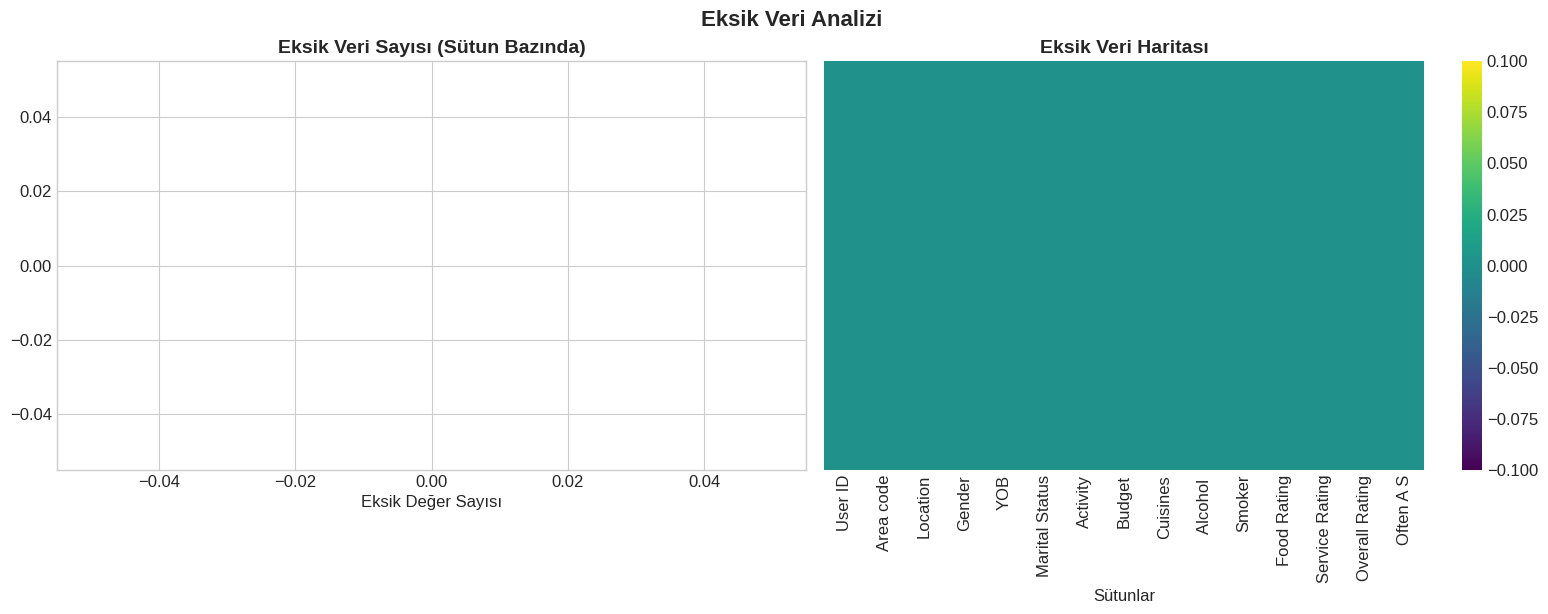

In [53]:
# Eksik veri görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
eksik_olan = df.isnull().sum()
eksik_olan = eksik_olan[eksik_olan > 0].sort_values(ascending=True)

colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db'
          for x in (eksik_olan / len(df) * 100)]

axes[0].barh(eksik_olan.index, eksik_olan.values, color=colors)
axes[0].set_title('Eksik Veri Sayısı (Sütun Bazında)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Eksik Değer Sayısı')
for i, (val, col) in enumerate(zip(eksik_olan.values, eksik_olan.index)):
    axes[0].text(val + 1, i, f'{val} ({val/len(df)*100:.1f}%)', va='center')

# Heatmap
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis',
            ax=axes[1])
axes[1].set_title('Eksik Veri Haritası', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sütunlar')

plt.tight_layout()
plt.suptitle('Eksik Veri Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.show()

## **Eksik Veri Stratejileri**

In [ ]:
# Veri setimde eksik veri olmadığından dolayı eklemedim.

## **Tek Değişkenli Analiz**

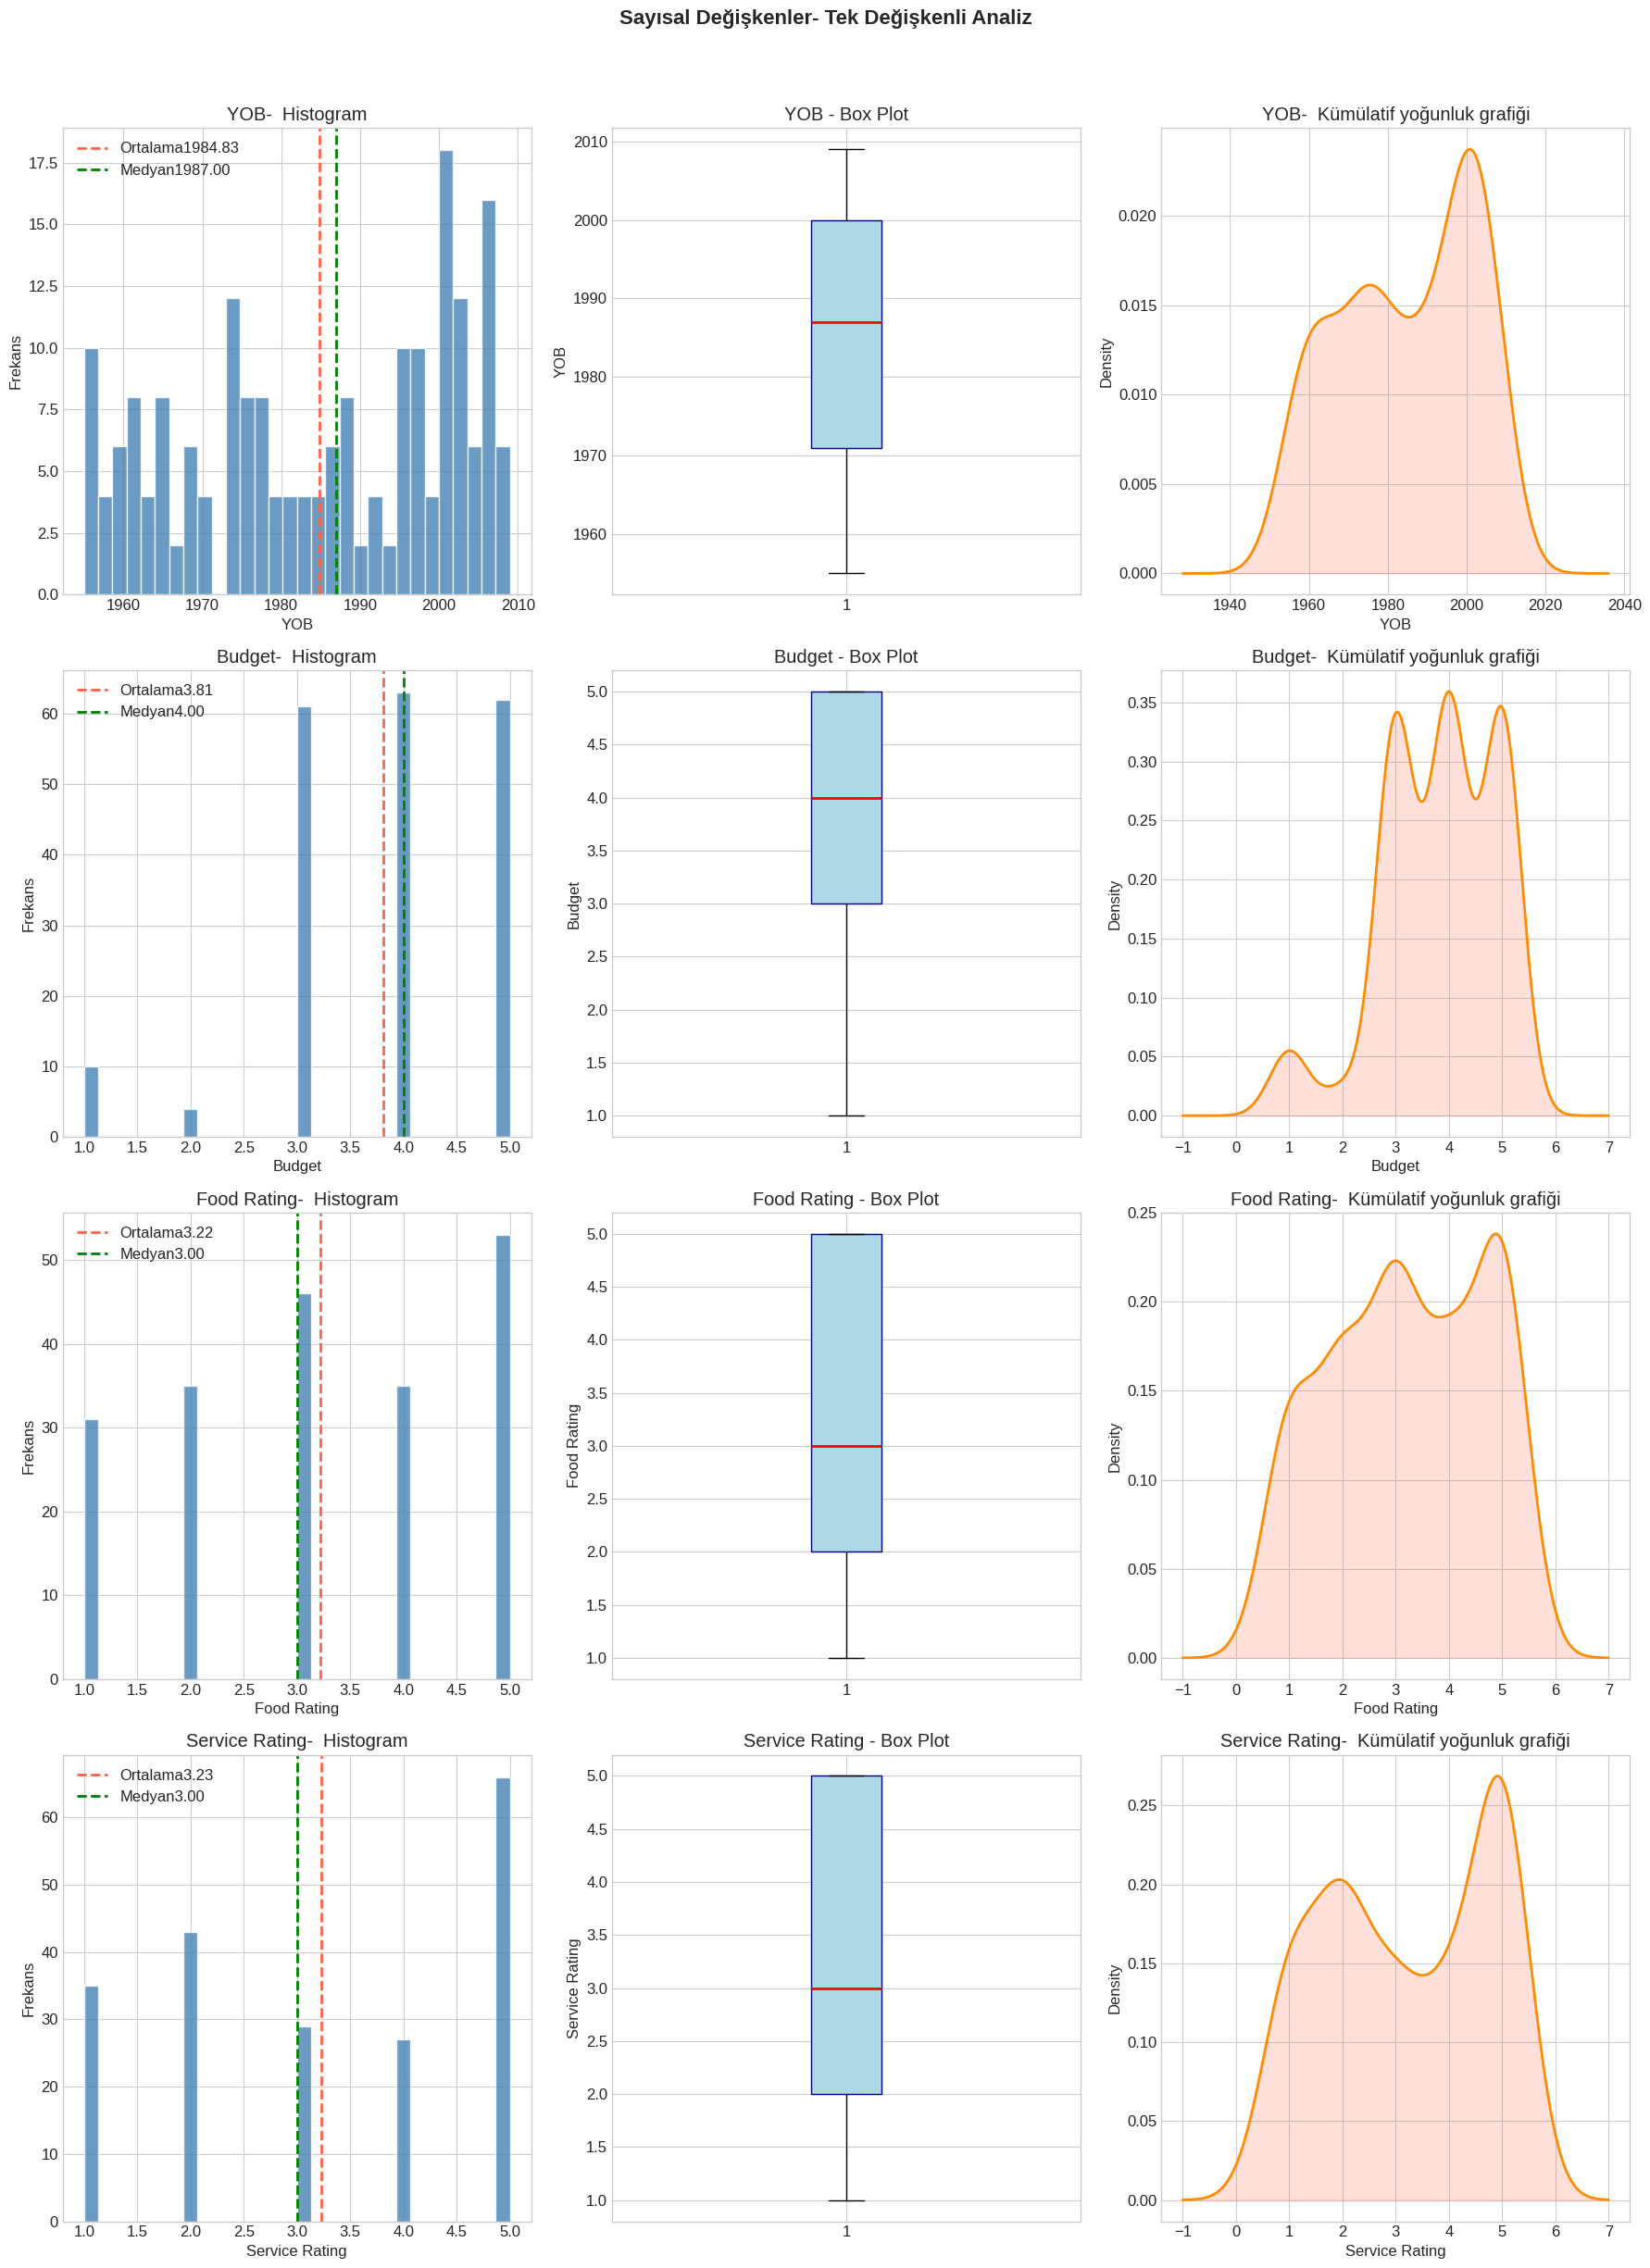

In [54]:
# sayısal değişkenler

sayisal_kolonlar =['YOB','Budget','Food Rating','Service Rating']

fig, axes = plt.subplots(len(sayisal_kolonlar), 3 , figsize=(18, 6*len(sayisal_kolonlar)))

for i, kolon in enumerate(sayisal_kolonlar):
  veri = df_temiz[kolon].dropna()

  axes[i,0].hist(veri, bins=30, color="steelblue",edgecolor='white',alpha=0.8)
  axes[i,0].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ortalama{veri.mean():.2f}')
  axes[i,0].axvline(veri.median(), color='green', linestyle='dashed', linewidth=2, label=f'Medyan{veri.median():.2f}')
  axes[i,0].set_title(f'{kolon}-  Histogram')
  axes[i,0].legend()
  axes[i,0].set_xlabel(kolon)
  axes[i,0].set_ylabel('Frekans')

      # Box plot
  axes[i, 1].boxplot(veri, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
  axes[i, 1].set_title(f'{kolon} - Box Plot')
  axes[i, 1].set_ylabel(kolon)


  veri.plot.kde(ax=axes[i,2],color='darkorange',linewidth=2)
  axes[i,2].fill_between(axes[i,2].lines[0].get_xdata(),
                        axes[i,2].lines[0].get_ydata(),
                        color='tomato',alpha=0.2)
  axes[i,2].set_title(f'{kolon}-  Kümülatif yoğunluk grafiği')
  axes[i,2].set_xlabel(kolon)


plt.suptitle('Sayısal Değişkenler- Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [56]:
# istatiksel özet tablo
print('Sayısal Değişkenler detaylı İstatistikler:')
print('='*70)


for kolon in sayisal_kolonlar :
  veri=df_temiz[kolon].dropna()
  print(f'\n * {kolon.upper()}')
  print(f'Ortalama: {veri.mean():.2f}')
  print(f'Medyan: {veri.median():.2f}')
  print(f'Standart Sapma: {veri.std():.2f}')
  print(f'Minimum: {veri.min():.2f}')
  print(f'Maksimum: {veri.max():.2f}')
  print(f'Varyans: {veri.var():.2f}')
  print(f'Skewness(Çarpıklık): {veri.skew():.2f}')
  print(f'Kurtosis(Basıklık): {veri.kurtosis():.2f}')
  print(f'IQR: {veri.quantile(0.75)-veri.quantile(0.25):.2f}')
  print('='*70)

Sayısal Değişkenler detaylı İstatistikler:

 * YOB
Ortalama: 1984.83
Medyan: 1987.00
Standart Sapma: 16.81
Minimum: 1955.00
Maksimum: 2009.00
Varyans: 282.55
Skewness(Çarpıklık): -0.25
Kurtosis(Basıklık): -1.29
IQR: 29.00

 * BUDGET
Ortalama: 3.81
Medyan: 4.00
Standart Sapma: 1.06
Minimum: 1.00
Maksimum: 5.00
Varyans: 1.12
Skewness(Çarpıklık): -0.76
Kurtosis(Basıklık): 0.36
IQR: 2.00

 * FOOD RATING
Ortalama: 3.22
Medyan: 3.00
Standart Sapma: 1.41
Minimum: 1.00
Maksimum: 5.00
Varyans: 1.99
Skewness(Çarpıklık): -0.16
Kurtosis(Basıklık): -1.25
IQR: 3.00

 * SERVICE RATING
Ortalama: 3.23
Medyan: 3.00
Standart Sapma: 1.53
Minimum: 1.00
Maksimum: 5.00
Varyans: 2.33
Skewness(Çarpıklık): -0.13
Kurtosis(Basıklık): -1.50
IQR: 3.00


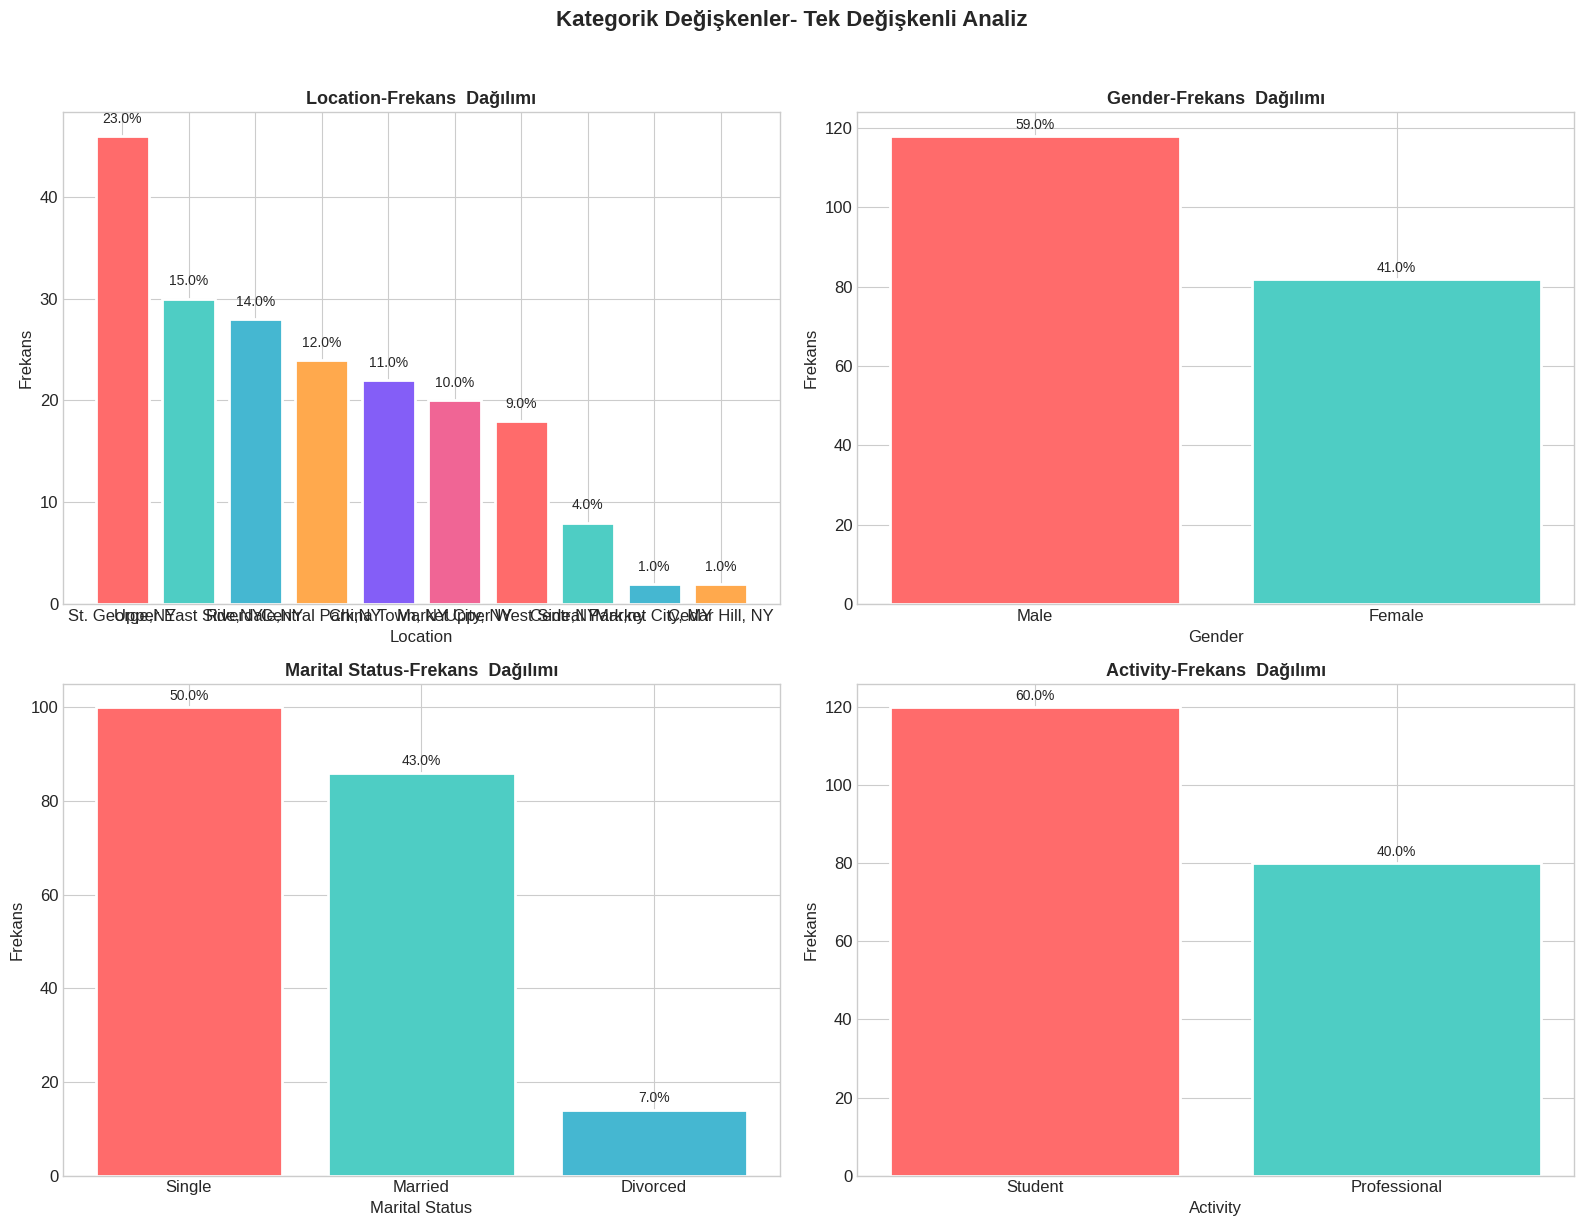

In [57]:
kategorik_kolonlar = ['Location','Gender','Marital Status','Activity']
fig,axes =  plt.subplots(2,2,figsize=(16,12))
axes=axes.flatten()

renkler = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA94D', '#845EF7', '#F06595']
for i,kolon in enumerate(kategorik_kolonlar):
  degerler=df_temiz[kolon].value_counts()
  yuzde = (degerler/len(df_temiz)*100).round(2)


  bars = axes[i].bar(degerler.index.astype(str),degerler.values,
                     color = renkler[:len(degerler)],edgecolor='white',linewidth=2)

  axes[i].set_title(f'{kolon}-Frekans  Dağılımı',fontsize=13,fontweight='bold')
  axes[i].set_xlabel(kolon)
  axes[i].set_ylabel('Frekans')

  for bar ,pct in zip(bars,yuzde.values):
    axes[i].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1,
                 f'{pct}%',
                 ha='center',
                 va='bottom',
                 fontsize=10)
plt.suptitle('Kategorik Değişkenler- Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Çift değişkenli Analiz

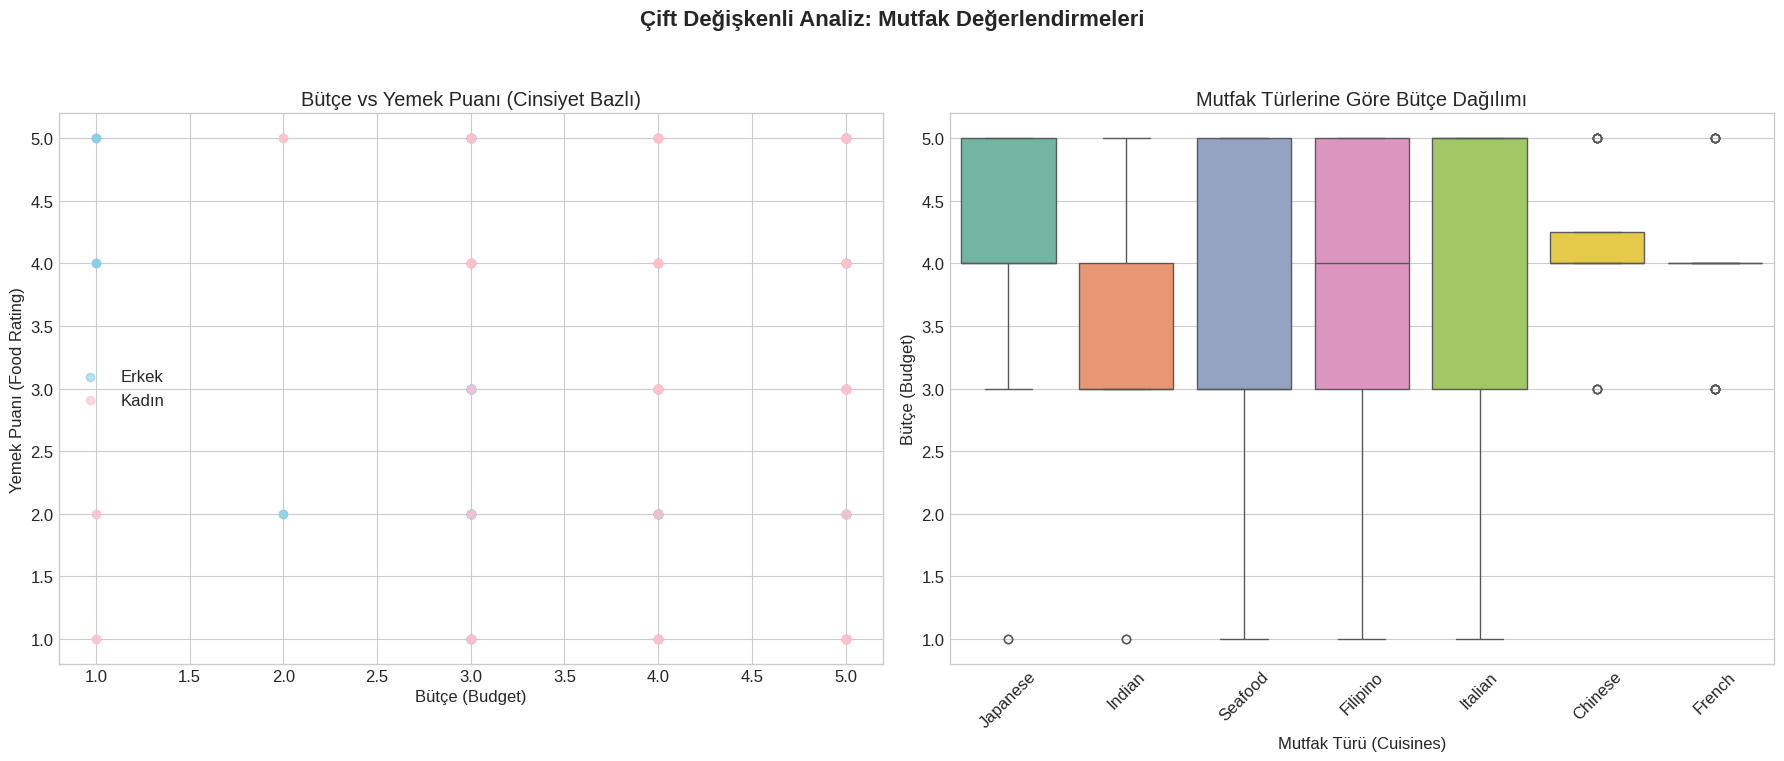

In [58]:
# Sayısal vs Sayısal ve Sayısal vs Kategorik Analizi

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. Bütçe vs Yemek Puanı (Cinsiyete göre ayrılmış)
male_df = df_temiz[df_temiz['Gender'] == 'Male']
female_df = df_temiz[df_temiz['Gender'] == 'Female']

axes[0].scatter(male_df['Budget'], male_df['Food Rating'], color='skyblue', label='Erkek', alpha=0.6)
axes[0].scatter(female_df['Budget'], female_df['Food Rating'], color='pink', label='Kadın', alpha=0.6)
axes[0].set_xlabel('Bütçe (Budget)')
axes[0].set_ylabel('Yemek Puanı (Food Rating)')
axes[0].set_title('Bütçe vs Yemek Puanı (Cinsiyet Bazlı)')
axes[0].legend()

# 2. Mutfak Türü vs Bütçe (Box Plot)
sns.boxplot(x='Cuisines', y='Budget', data=df_temiz, ax=axes[1], palette='Set2')
axes[1].set_xlabel('Mutfak Türü (Cuisines)')
axes[1].set_ylabel('Bütçe (Budget)')
axes[1].set_title('Mutfak Türlerine Göre Bütçe Dağılımı')
plt.xticks(rotation=45)

plt.suptitle('Çift Değişkenli Analiz: Mutfak Değerlendirmeleri', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

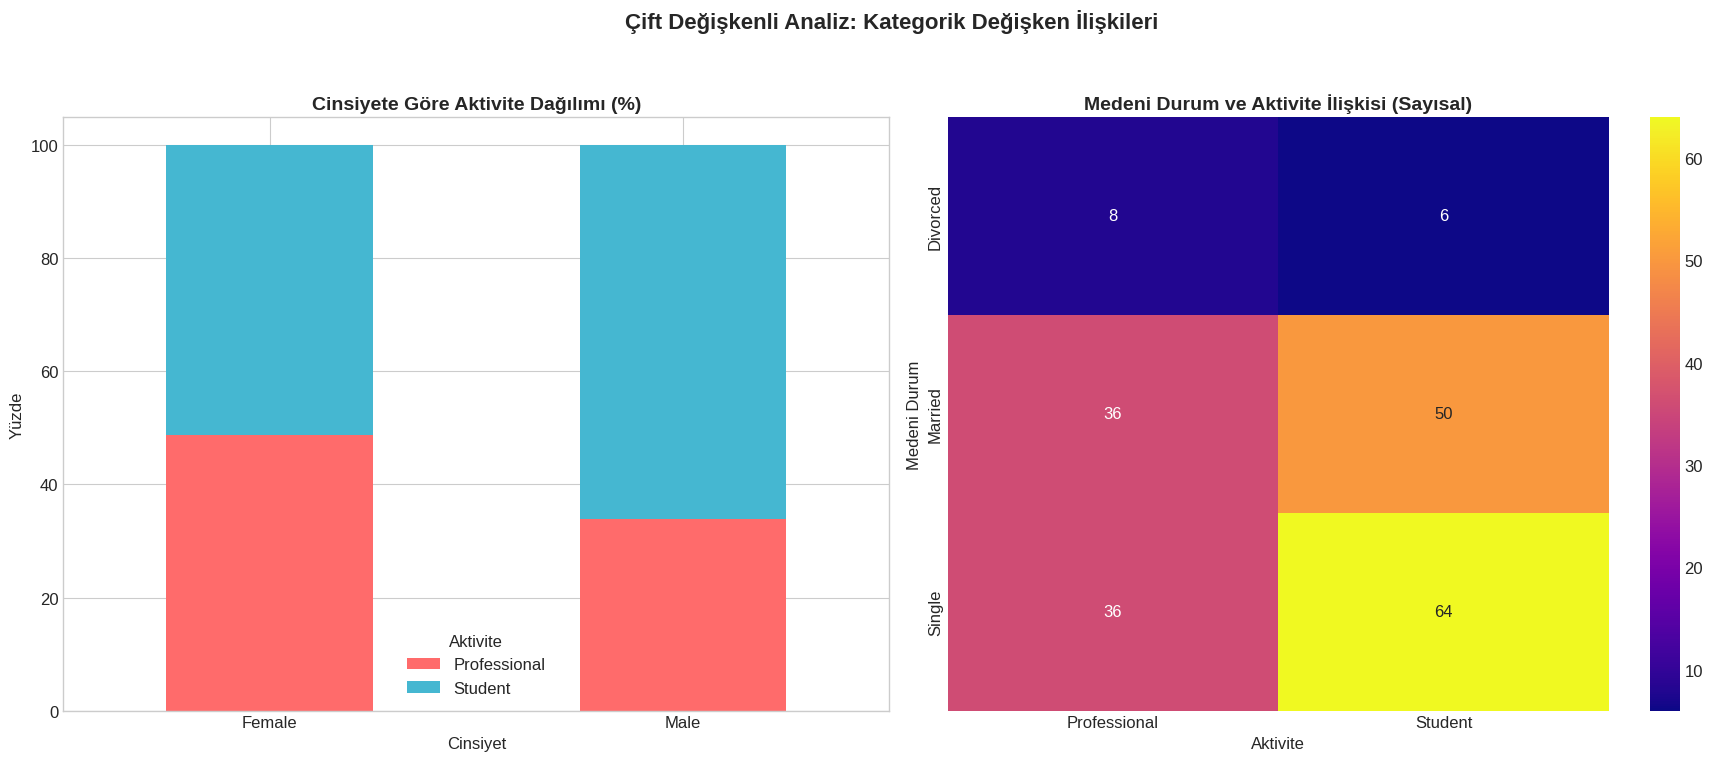

In [59]:
# Kategorik vs Kategorik Analizi (Cinsiyet, Medeni Durum ve Aktivite)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. Cinsiyet ve Aktivite (Öğrenci/Profesyonel) Oranı
# Titanic'teki sex/survived yerine Gender/Activity kullanıyoruz
ct_pct = pd.crosstab(df_temiz['Gender'], df_temiz['Activity'], normalize='index') * 100
ct_pct.plot(kind='bar', stacked=True, ax=axes[0], color=['#FF6B6B', '#45B7D1'])

axes[0].set_title('Cinsiyete Göre Aktivite Dağılımı (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cinsiyet')
axes[0].set_ylabel('Yüzde')
axes[0].legend(title='Aktivite')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# 2. Medeni Durum ve Aktivite (Heatmap)
# Titanic'teki pclass yerine Marital Status kullanıyoruz
ct2 = pd.crosstab(df_temiz['Marital Status'], df_temiz['Activity'])

sns.heatmap(ct2, annot=True, fmt='d', cmap='plasma', ax=axes[1])
axes[1].set_title('Medeni Durum ve Aktivite İlişkisi (Sayısal)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Aktivite')
axes[1].set_ylabel('Medeni Durum')

plt.suptitle('Çift Değişkenli Analiz: Kategorik Değişken İlişkileri', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

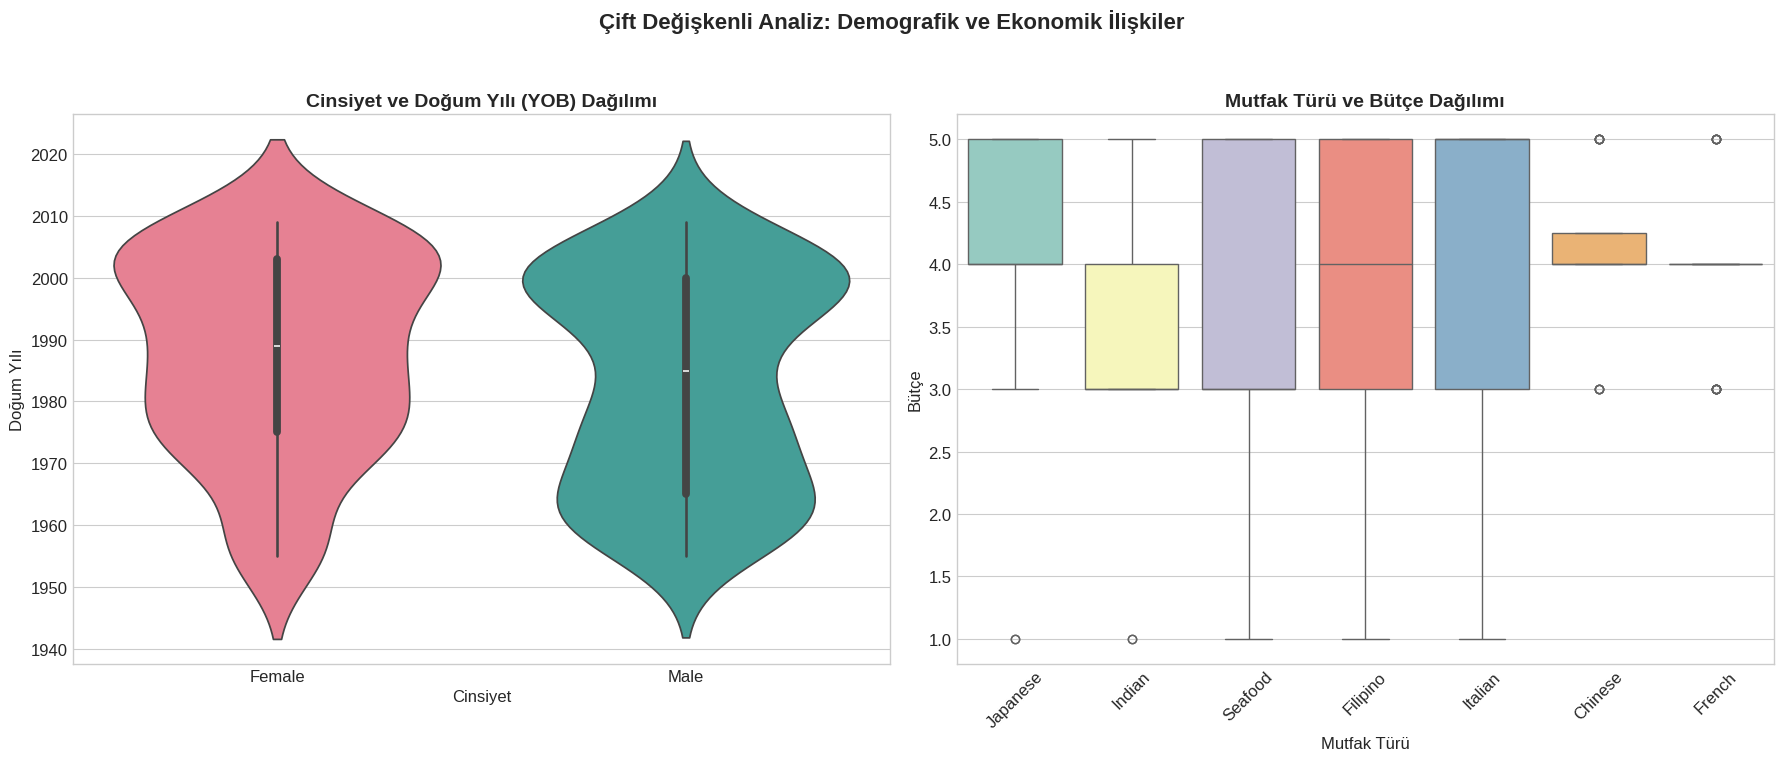

In [60]:
# Kategorik vs Sayısal Analizi

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. Cinsiyete göre Doğum Yılı (YOB) Dağılımı
# Titanic'teki sex/age yerine Gender/YOB kullanıyoruz
sns.violinplot(data=df_temiz, x='Gender', y='YOB', ax=axes[0], palette='husl')
axes[0].set_title('Cinsiyet ve Doğum Yılı (YOB) Dağılımı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cinsiyet')
axes[0].set_ylabel('Doğum Yılı')

# 2. Mutfak Türüne Göre Bütçe Dağılımı
# Titanic'teki pclass/age yerine Cuisines/Budget kullanıyoruz
sns.boxplot(data=df_temiz, x='Cuisines', y='Budget', ax=axes[1], palette='Set3')
axes[1].set_title('Mutfak Türü ve Bütçe Dağılımı', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mutfak Türü')
axes[1].set_ylabel('Bütçe')
plt.xticks(rotation=45)

plt.suptitle('Çift Değişkenli Analiz: Demografik ve Ekonomik İlişkiler', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()